In [476]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-performance-multiple-linear-regression/Student_Performance.csv


In [477]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/student-performance-multiple-linear-regression


In [478]:
df=pd.read_csv('/kaggle/input/student-performance-multiple-linear-regression/Student_Performance.csv')

In [479]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [480]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [481]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [482]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [483]:
df.duplicated().sum()

127

In [484]:
df.drop_duplicates(inplace=True)

In [485]:
df.duplicated().sum()

0

In [486]:
df.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

In [487]:
df['Extracurricular Activities'].value_counts()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64

In [488]:
df['Extracurricular Activities']=pd.get_dummies(df['Extracurricular Activities'],drop_first=True).astype(int)

In [489]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [490]:
df.std()

Hours Studied                        2.589081
Previous Scores                     17.325601
Extracurricular Activities           0.500000
Sleep Hours                          1.697683
Sample Question Papers Practiced     2.867202
Performance Index                   19.208570
dtype: float64

In [491]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

original_columns = ['Previous Scores', 'Performance Index']

sc = StandardScaler()
scaled_data = sc.fit_transform(df[original_columns])  

df_scaled = pd.DataFrame(scaled_data, columns=original_columns)


In [492]:
df.std()

Hours Studied                        2.589081
Previous Scores                     17.325601
Extracurricular Activities           0.500000
Sleep Hours                          1.697683
Sample Question Papers Practiced     2.867202
Performance Index                   19.208570
dtype: float64

In [493]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [494]:
df.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities            int64
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

In [495]:
X=df.drop('Performance Index',axis=1)
Y=df['Performance Index']
Y = Y.loc[X.index]

In [496]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)


In [497]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
model.predict(x_test)

array([46.47091936, 80.24923008, 61.02996578, ..., 29.51491428,
       51.34505597, 64.87860811])

In [498]:
model.score(x_test,model.predict(x_test))

1.0

In [499]:
x_train.shape

(6911, 5)

In [500]:
y_train.shape

(6911,)

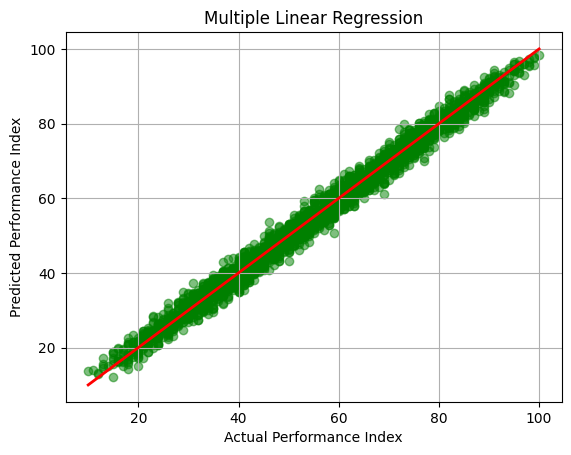

In [501]:
import matplotlib.pyplot as plt
plt.scatter(y_test,model.predict(x_test), alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Multiple Linear Regression')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid(True)
plt.show()

In [502]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,model.predict(x_test))
mae=mean_absolute_error(y_test,model.predict(x_test))
rmse=np.sqrt(mse)
score=r2_score(y_test,model.predict(x_test))
mse

4.326180232071976

In [503]:
mae

1.646199745534188

In [504]:
score

0.9881593003934889

In [505]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=10**2) 
ridge_model.fit(x_train, y_train)
y_pred_ridge = ridge_model.predict(x_test)
print(f"R² Score for Ridge: {r2_score(y_test, y_pred_ridge)}")
print (f"MSE for Ridge : {mean_squared_error(y_test, y_pred_ridge)}")

R² Score for Ridge: 0.9881455590550641
MSE for Ridge : 4.331200839690688


In [506]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=10**2) 
lasso_model.fit(x_train, y_train)

y_pred_lasso = lasso_model.predict(x_test)
print(f"R² Score for Lasso: {r2_score(y_test, y_pred_lasso)}")
print (f"MSE for Lasso : {mean_squared_error(y_test, y_pred_lasso)}")

R² Score for Lasso: 0.7470931395330719
MSE for Lasso : 92.40337958626667


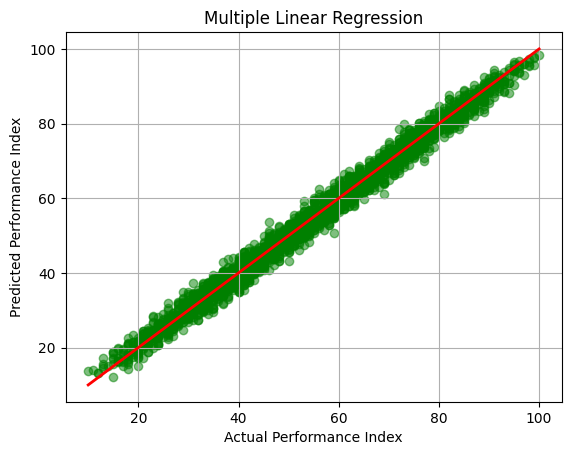

In [511]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred_ridge, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Multiple Linear Regression')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid(True)
plt.show()